# Tutorial: Evaluating Large Language Models on Everyday Moral Dilemmas

**Learning Objectives:**
- Learn how to replicate findings from a computational social science research paper
- Work with real-world text data from Reddit and LLM judgments
- Apply statistical measures of agreement (Krippendorff's alpha)
- Visualize patterns in model behavior and moral reasoning
- Understand how to critically evaluate AI systems

---

## Background

This tutorial is based on the paper ["Normative Evaluation of Large Language Models with Everyday Moral Dilemmas"](https://dl.acm.org/doi/10.1145/3715275.3732044) by Sachdeva & van Nuenen (2025). 

### Research Question

As Large Language Models (LLMs) are increasingly used for tasks requiring ethical judgment—from content moderation to mental health support—we need to understand how they reason about moral dilemmas. Do different models agree on what's right and wrong? How do their judgments compare to human consensus?

### Dataset: r/AmItheAsshole (AITA)

We used Reddit's AITA community, where people describe moral dilemmas and ask: "Am I the Asshole?" Community members vote using these labels:

- **NTA** (Not the Asshole): Original poster (OP) is not at fault
- **YTA** (You're the Asshole): OP is at fault  
- **NAH** (No Assholes Here): Neither party is at fault
- **ESH** (Everyone Sucks Here): Both parties are at fault
- **INFO**: Not enough information to judge

We prompted 7 different LLMs to judge over 10,000 real AITA scenarios and compared their verdicts to human judgments.

### What We'll Replicate

In this tutorial, we'll reproduce three key findings:
1. **Figure 1**: How verdict distributions differ between models and humans
2. **Figure 2**: How consistent models are (with themselves and each other)
3. **Figure 5**: What moral themes different models invoke in their reasoning


## Part 1: Setup and Data Loading

First, let's install and import the libraries we'll need.

In [1]:
# Install required packages (uncomment if needed)
# !pip install datasets pandas numpy matplotlib seaborn krippendorff
%pip install krippendorff

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import krippendorff
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style for prettier plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


### Load the Dataset

The dataset is hosted on Hugging Face and contains:
- 10,826 AITA scenarios
- Verdicts from Redditors (crowd consensus)
- Verdicts from 7 LLMs, each run 3 times (for consistency testing)
- The models' explanations/reasoning for their verdicts
- Moral theme classifications

In [ ]:
# Load the dataset from Hugging Face
dataset = load_dataset("ucberkeley-dlab/normative_evaluation_llms_everyday_dilemmas")
dataset # this DatasetDict is not fully loaded into memory / Stored in an efficient HF/Arrow format


DatasetDict({
    test: Dataset({
        features: ['submission_id', 'title', 'selftext', 'created_utc', 'permalink', 'score', 'flair_text', 'top_comment', 'comments_nta_agreement', 'comments_yta_agreement', 'comments_esh_agreement', 'comments_nah_agreement', 'comments_nta_agreement_weighted', 'comments_yta_agreement_weighted', 'comments_esh_agreement_weighted', 'comments_nah_agreement_weighted', 'reddit_label', 'gpt3.5_label_1', 'gpt3.5_reason_1', 'gpt3.5_label_2', 'gpt3.5_reason_2', 'gpt3.5_label_3', 'gpt3.5_reason_3', 'gpt4_label_1', 'gpt4_reason_1', 'gpt4_label_2', 'gpt4_reason_2', 'gpt4_label_3', 'gpt4_reason_3', 'claude_label_1', 'claude_reason_1', 'claude_label_2', 'claude_reason_2', 'claude_label_3', 'claude_reason_3', 'bison_label_1', 'bison_reason_1', 'bison_label_2', 'bison_reason_2', 'bison_label_3', 'bison_reason_3', 'gemma_label_1', 'gemma_reason_1', 'gemma_label_2', 'gemma_reason_2', 'gemma_label_3', 'gemma_reason_3', 'gemma_label_4', 'gemma_reason_4', 'gemma_label_5', 

In [3]:
df = dataset["test"].to_pandas() #huggingface method to convert to df 

In [4]:
df.shape

(10826, 171)

In [5]:
df.columns.to_list()

['submission_id',
 'title',
 'selftext',
 'created_utc',
 'permalink',
 'score',
 'flair_text',
 'top_comment',
 'comments_nta_agreement',
 'comments_yta_agreement',
 'comments_esh_agreement',
 'comments_nah_agreement',
 'comments_nta_agreement_weighted',
 'comments_yta_agreement_weighted',
 'comments_esh_agreement_weighted',
 'comments_nah_agreement_weighted',
 'reddit_label',
 'gpt3.5_label_1',
 'gpt3.5_reason_1',
 'gpt3.5_label_2',
 'gpt3.5_reason_2',
 'gpt3.5_label_3',
 'gpt3.5_reason_3',
 'gpt4_label_1',
 'gpt4_reason_1',
 'gpt4_label_2',
 'gpt4_reason_2',
 'gpt4_label_3',
 'gpt4_reason_3',
 'claude_label_1',
 'claude_reason_1',
 'claude_label_2',
 'claude_reason_2',
 'claude_label_3',
 'claude_reason_3',
 'bison_label_1',
 'bison_reason_1',
 'bison_label_2',
 'bison_reason_2',
 'bison_label_3',
 'bison_reason_3',
 'gemma_label_1',
 'gemma_reason_1',
 'gemma_label_2',
 'gemma_reason_2',
 'gemma_label_3',
 'gemma_reason_3',
 'gemma_label_4',
 'gemma_reason_4',
 'gemma_label_5',
 'g

In [6]:
# Look at one example scenario

print(df['selftext'].iloc[1])

My mom got married 5 years ago. I was 11. I knew her husband for years before she married him because his son and I have been in school together since kindergarten. I don't like his son. Never did. As far as I know he's not like an instigator kind of bully but he is the kind of person who finds it funny when something embarrassing happens to a kid, he's the kind of person who will bring it up again and again, he's also the kind of person who uses slurs. Even now at 16 he's not all that different from when he was 6.

My mom and her husband over the years have tried to make the four of us a family. They have spent a lot of money and time trying to create these bonding moments and memories to look back on fondly but my favorite part of all those moments was spending time with my mom, not her husband's son. I still wouldn't call him family or my sibling. I wouldn't call him a friend either.

Ever since April his friends and him have seen each other way less, because his dad and some of his

In [26]:
# Get unique values from all columns with 'label' in the name
label_cols = [col for col in df.columns if 'label' in col]
for col in label_cols:
    print(df[col].unique())

['NTA' 'YTA' 'ESH' 'INFO' 'NAH']
['NTA' 'YTA' 'ESH' 'INFO' 'NAH']
['NTA' 'YTA' 'ESH' 'INFO' 'NAH']
['NTA' 'ESH' 'YTA' 'INFO' 'NAH']
['NTA' 'NAH' 'YTA' 'ESH' 'INFO']
['NTA' 'YTA' 'ESH' 'NAH' 'INFO']
['NAN']
['NTA' 'ESH' 'YTA' 'NAH' 'INFO']
['NTA' 'ESH' 'YTA' 'NAH' 'INFO']
['NTA' 'ESH' 'YTA' 'NAH' 'INFO']
['NTA' 'YTA' 'NAH' 'ESH' 'INFO']
['NTA' 'YTA' 'ESH' 'NAH']
['NTA' 'YTA' 'NAH' 'ESH']
['NTA' 'ESH' 'YTA' 'NAH' 'INFO']
['NTA' 'YTA' 'ESH' 'NAH' 'INFO']
['NTA' 'YTA' 'ESH' 'NAH']
['NTA' 'YTA' 'ESH' 'NAH']
['NTA' 'YTA' 'ESH' 'NAH']
['NAH' 'INFO' 'ESH' 'NTA' 'YTA']
['NAH' 'ESH' 'INFO' 'YTA' 'NTA']
['NAH' 'ESH' 'INFO' 'YTA' 'NTA']
['YTA' 'NAH' 'ESH' 'NTA']
['NAH' 'YTA' 'ESH' 'NTA']
['YTA' 'NAH' 'ESH' 'NTA']
['FALSE' 'TRUE']
['TRUE' 'FALSE']
['TRUE' 'FALSE']
['FALSE' 'TRUE']
['TRUE' 'FALSE']
['FALSE' 'TRUE']
['FALSE' 'TRUE']
['FALSE' 'TRUE']
['TRUE' 'FALSE']
['FALSE' 'TRUE']
['TRUE' 'FALSE']
['TRUE' 'FALSE']
['FALSE' 'TRUE']
['FALSE' 'TRUE']
['TRUE' 'FALSE']
['FALSE' 'TRUE']
['TRUE' 'FALSE']


In [ ]:
# Convert everything to uppercase strings and fix INF -> INFO
for col in df.columns:
    if 'label' in col:
        df[col] = df[col].astype(str).str.upper().str.strip()
        df[col] = df[col].replace({'INF': 'INFO'})

verdicts = ['NTA', 'YTA', 'NAH', 'ESH', 'INFO']

##  Figure 1 - Verdict Distributions

**Research Question:** How do different models and humans distribute their moral judgments?

This tells us about potential biases. For example:
- Does a model almost always say "NTA" (too lenient)?
- Does it overuse "YTA" (too harsh)?
- Does it match human patterns?

In [27]:
models = [
    "Redditor", "GPT-3.5", "GPT-4", "Claude Haiku",
    "PaLM 2 Bison", "Llama 2 7B", "Mistral 7B", "Gemma 7B"
]

label_cols = [
    'reddit_label',
    'gpt3.5_label_1',
    'gpt4_label_1',
    'claude_label_1',
    'bison_label_1',
    'llama_label_1',
    'mistral_label_1',
    'gemma_label_1'
]

In [28]:
dist_df = (
    df[label_cols]
      .apply(lambda c: c.value_counts(normalize=True))
      .fillna(0)
      .loc[verdicts]
      .T
)

dist_df.index = models

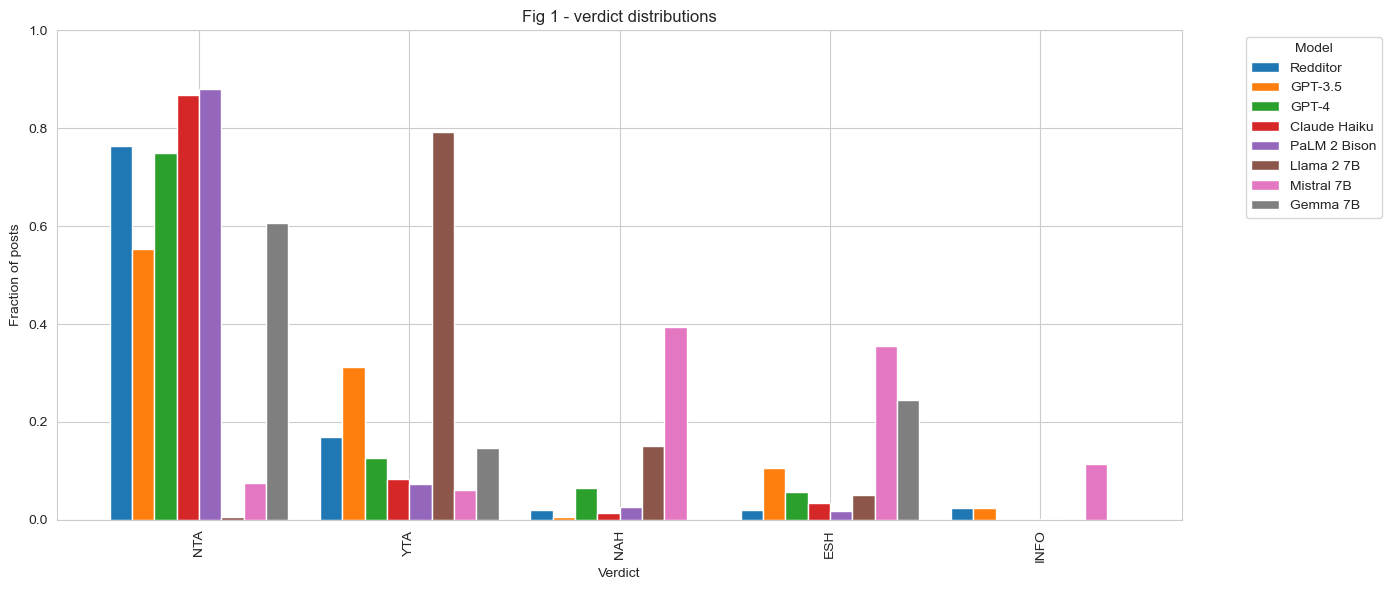

In [29]:
# PLOT FIGURE 1
ax = dist_df.T.plot(kind='bar', figsize=(14, 6), width=0.85)
ax.set_xlabel("Verdict")
ax.set_ylabel("Fraction of posts")
ax.set_ylim(0,1)
ax.set_title("Fig 1 - verdict distributions")
ax.legend(title="Model", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()

**Critical Thinking Exercise:** 

1. Why might Llama 2 be so harsh (mostly YTA)? 
2. What are the implications of a model that's biased toward blaming people?
3. If you were using an LLM as a mental health chatbot, which verdict pattern would concern you most?

# Figure 2 - Model Agreement and Self-Consistency

**Research Question:** How much do models agree with each other? How consistent is each model with itself?

### Understanding Krippendorff's Alpha (α)

Krippendorff's alpha measures agreement between annotators (in our case, models or runs). It ranges from -1 to 1:

- **α = 1**: Perfect agreement
- **α = 0**: No agreement beyond chance
- **α < 0**: Systematic disagreement
- **α > 0.67**: Generally considered reliable agreement

We'll calculate:
1. **Inter-model agreement**: How much do different models agree?
2. **Self-consistency**: How much does each model agree with itself across runs?

In [ ]:
# Code mapping
codes = {'NTA':0, 'YTA':1, 'NAH':2, 'ESH':3, 'INFO':4}

rating = (
    df[label_cols]
      .replace(codes)
      .astype(float) # integers cannot hold NaN, floats can!
      .to_numpy() # Krippendorff’s function requires a NumPy array, not a DataFrame
      .T # Krippendorff expects (models, posts), not (posts, models)
)

# Pairwise agreement
n = len(models) # this will be 8
agree = np.full((n,n), np.nan) # empty 8*8 matrix

In [ ]:
for i in range(n):
    for j in range(i+1,n):
        pair = np.vstack([rating[i], rating[j]])
        agree[i,j] = krippendorff.alpha(pair, level_of_measurement='nominal')
        agree[j,i] = agree[i,j]

In [ ]:
# Self-consistency using run counts from paper
runs = {
    'GPT-3.5': ['gpt3.5_label_1','gpt3.5_label_2','gpt3.5_label_3'],
    'GPT-4':   ['gpt4_label_1','gpt4_label_2'],  # only 2 runs in paper
    'Claude Haiku': ['claude_label_1','claude_label_2','claude_label_3'],
    'PaLM 2 Bison': ['bison_label_1','bison_label_2','bison_label_3'],
    'Llama 2 7B': ['llama_label_1','llama_label_2','llama_label_3'],
    'Mistral 7B': ['mistral_label_1','mistral_label_2','mistral_label_3'],
    'Gemma 7B': ['gemma_label_1','gemma_label_2','gemma_label_3']
}

In [ ]:
self_consistency = {}

for i, model in enumerate(models):
    if model in runs:
        x = df[runs[model]].replace(codes).astype(float).to_numpy().T
        x[(x<0)|(x>4)] = np.nan
        self_consistency[model] = krippendorff.alpha(x, level_of_measurement='nominal')
        agree[i,i] = self_consistency[model]  # diagonal

agreement_df = pd.DataFrame(agree, index=models, columns=models)

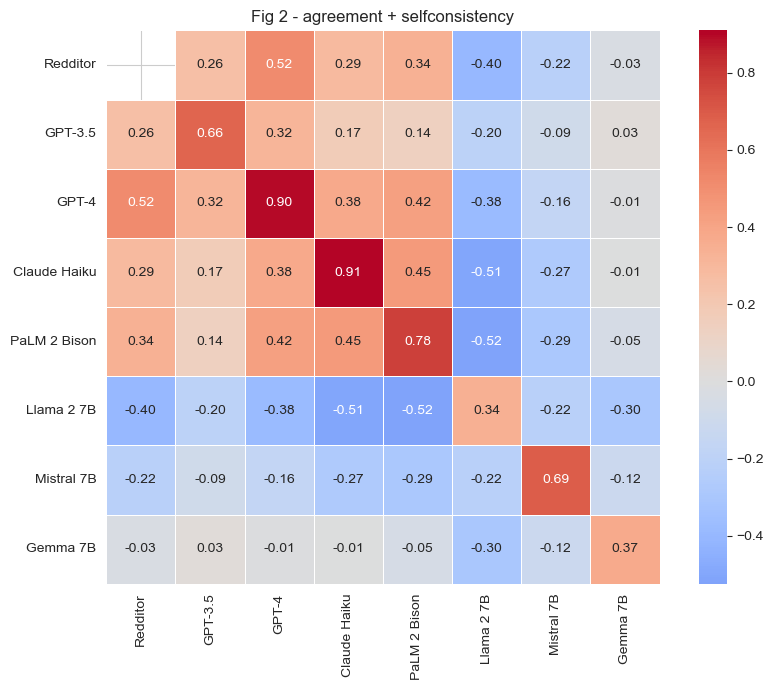

In [ ]:
plt.figure(figsize=(9,7))
sns.heatmap(
    agreement_df,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    square=True, linewidths=.5
)
plt.title("Fig 2 - agreement + selfconsistency")
plt.tight_layout()
plt.show()

**Interpretation Guide:**

- **Diagonal (self-consistency)**: How reliable is each model?
  - GPT-4, Claude: High (0.85-0.89) - very consistent
  - Llama 2, Gemma: Low (0.37-0.41) - inconsistent, unreliable

- **Off-diagonal (inter-model agreement)**: Do models agree with each other?
  - Mostly low positive or negative values
  - Even "good" models like GPT-4 and Claude only moderately agree (0.32)
  - This suggests models have fundamentally different moral frameworks!

**Discussion Question:** What are the implications of low inter-model agreement for AI safety? If we deploy these models in high-stakes applications (content moderation, therapy), should we be concerned?

In [ ]:
models = [
    'GPT-3.5', 'GPT-4', 'Claude', 'Bison', 'Llama', 'Mistral', 'Gemma'
]

prob_cols = {
    'GPT-3.5': 'gpt3.5_reason_1_',
    'GPT-4': 'gpt4_reason_1_',
    'Claude': 'claude_reason_1_',
    'Bison': 'bison_reason_1_',
    'Llama': 'llama_reason_1_',
    'Mistral': 'mistral_reason_1_',
    'Gemma': 'gemma_reason_1_'
}

moral_dims = [
    'fairness', 'feelings', 'harms',
    'honesty', 'relational_obligation', 'social_norms'
]

In [ ]:
# Build summary df: models × moral dimensions
mean_probs = pd.DataFrame({
    model: [
        df[f"{prefix}{dim}_prob"].mean()
        for dim in moral_dims
    ]
    for model, prefix in model_cols.items()
}, index=moral_dims)


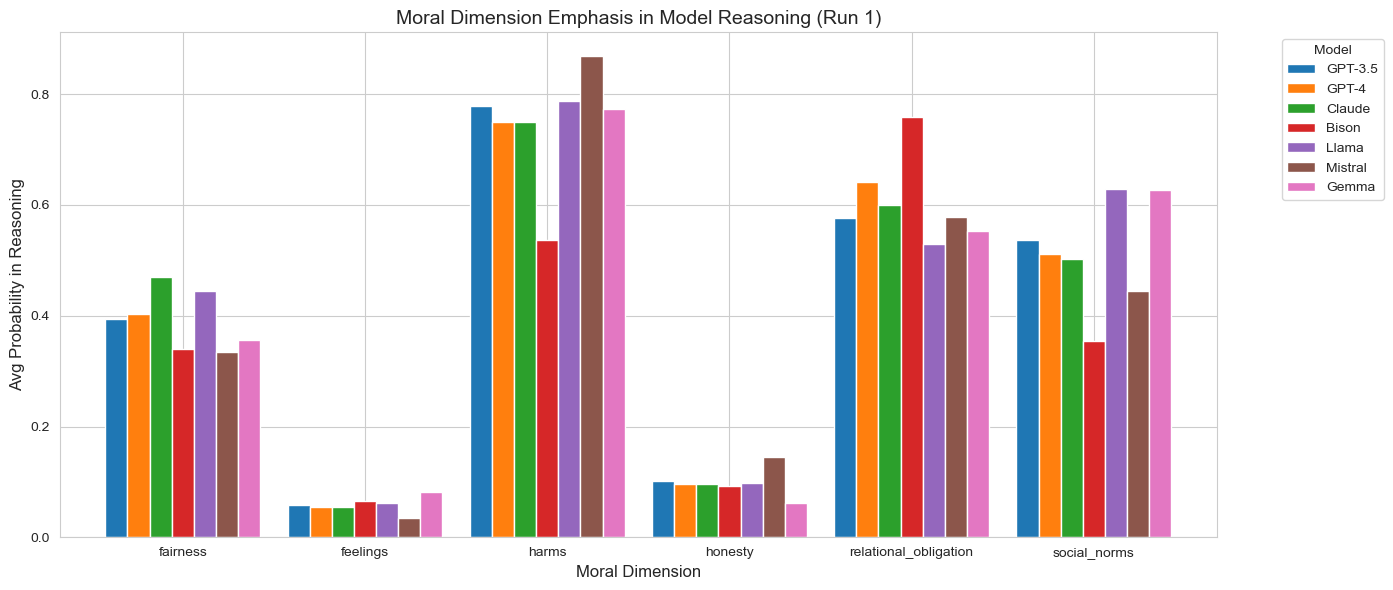

In [ ]:
# THIS is the important change → transpose for plotting
ax = mean_probs.T.plot(
    kind='bar',
    figsize=(14, 6),
    width=0.85
)

ax.set_xlabel("Moral Dimension", fontsize=12)
ax.set_ylabel("Avg Probability in Reasoning", fontsize=12)
ax.set_title("Moral Dimension Emphasis in Model Reasoning (Run 1)", fontsize=14)
plt.xticks(rotation=0)
ax.legend(title="Model", bbox_to_anchor=(1.05,1), loc="upper left")

plt.tight_layout()
plt.show()

## Key Takeaways

### Summary of Findings

Through replicating this research, we've learned:

1. **Verdict Distributions (Figure 1)**
   - Models vary dramatically in how harsh/lenient they are
   - Some models (Llama 2) show extreme biases
   - GPT-4 matches human patterns most closely

2. **Agreement & Consistency (Figure 2)**
   - Models have low inter-agreement: they disagree on moral judgments
   - Self-consistency varies: some models are reliable, others aren't
   - Even good models only moderately agree with humans

### Implications for AI Development

1. Different models have fundamentally different moral tastes
2. Self-consistency is crucial for deployment
3. LLMs may miss emotional nuance humans naturally consider
4. Users should know which model is making judgments

## Extensions & Further Exploration

Want to dig deeper? Try these exercises:

### 1. Explore Self-Consistency Across All Runs
- Calculate self-consistency using ALL three runs (we only used run 1 for plotting)
- Does it change the story?

### 2. Analyze Specific Disagreement Cases
```python
# Find scenarios where GPT-4 and Claude disagree
disagreement = df[
    (df['gpt4_verdict_run1'] == 'NTA') & 
    (df['claude_haiku_verdict_run1'] == 'YTA')
]
# Read some examples - what's different about these cases?
```

### 3. Moral Theme Combinations
- When models invoke both Harms AND Fairness, are they more likely to say YTA?
- Build a correlation matrix of themes

### 4. Temporal Analysis
- The dataset has timestamps - did model performance change over the 6-month period?

### 5. Your Own Research Question
- What would YOU want to know about these models?
- Form a hypothesis and test it with this data

## Additional Resources

- **Full Paper**: Sachdeva & van Nuenen (2025), "Normative Evaluation of Large Language Models with Everyday Moral Dilemmas"
- **Dataset**: https://huggingface.co/datasets/ucberkeley-dlab/normative_evaluation_llms_everyday_dilemmas
- **Krippendorff's Alpha**: https://en.wikipedia.org/wiki/Krippendorff%27s_alpha
- **Moral Foundations Theory**: Graham et al. (2013)
- **Reddit AITA Community**: r/AmItheAsshole

---

**Citation**: If you use this tutorial or dataset, please cite:

```
Sachdeva, P. S., & van Nuenen, T. (2025). 
Normative Evaluation of Large Language Models with Everyday Moral Dilemmas. 
arXiv:2501.18081v1 [cs.AI]
```